Download Titanic Dataset

In [1]:
import urllib.request

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
urllib.request.urlretrieve(url, "titanic.csv")

print("Dataset Downloaded Successfully!")

Dataset Downloaded Successfully!


# **TASK 1: DATA CLEANING & EDA**

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries Imported")

Libraries Imported


Load Dataset

In [3]:
df = pd.read_csv("titanic.csv")

print("Dataset Loaded")
print("Shape:", df.shape)

df.head()

Dataset Loaded
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Dataset Information

In [4]:
print("Dataset Information")

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Descriptive Statistics

In [5]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


Check Categorical Columns

In [6]:
print("Survival Count")
print(df["Survived"].value_counts())

print("\nPassenger Class")
print(df["Pclass"].value_counts())

print("\nGender Distribution")
print(df["Sex"].value_counts())

print("\nEmbarked")
print(df["Embarked"].value_counts())

Survival Count
Survived
0    549
1    342
Name: count, dtype: int64

Passenger Class
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Gender Distribution
Sex
male      577
female    314
Name: count, dtype: int64

Embarked
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Missing Values

In [7]:
missing = df.isnull().sum()

missing_percent = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

print(missing_df[missing_df["Missing Values"]>0])

          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467


Data Cleaning

In [8]:
# Drop Cabin column

df.drop("Cabin", axis=1, inplace=True)

# Fill Age with Median

df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill Embarked with Mode

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Remove Duplicates

In [9]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (891, 11)


Feature Engineering

In [10]:
bins = [0,12,18,35,60,100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Middle Age",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Young Adult,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Middle Age,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Young Adult,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Young Adult,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Young Adult,1,1


Survival Analysis

In [11]:
print("Survival Rate By Gender")

print(
    df.groupby("Sex")["Survived"].mean()*100
)

print("\nSurvival Rate By Class")

print(
    df.groupby("Pclass")["Survived"].mean()*100
)

print("\nAverage Fare By Class")

print(
    df.groupby("Pclass")["Fare"].mean()
)

Survival Rate By Gender
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate By Class
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Average Fare By Class
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


Correlation Matrix

In [12]:
corr = df[
    ["Survived","Pclass","Age","Fare","FamilySize"]
].corr()

print(corr)

            Survived    Pclass       Age      Fare  FamilySize
Survived    1.000000 -0.338481 -0.064910  0.257307    0.016639
Pclass     -0.338481  1.000000 -0.339898 -0.549500    0.065997
Age        -0.064910 -0.339898  1.000000  0.096688   -0.245619
Fare        0.257307 -0.549500  0.096688  1.000000    0.217138
FamilySize  0.016639  0.065997 -0.245619  0.217138    1.000000


# **TASK 2: ADVANCED VISUALIZATION**

Plot 1: Survival Count

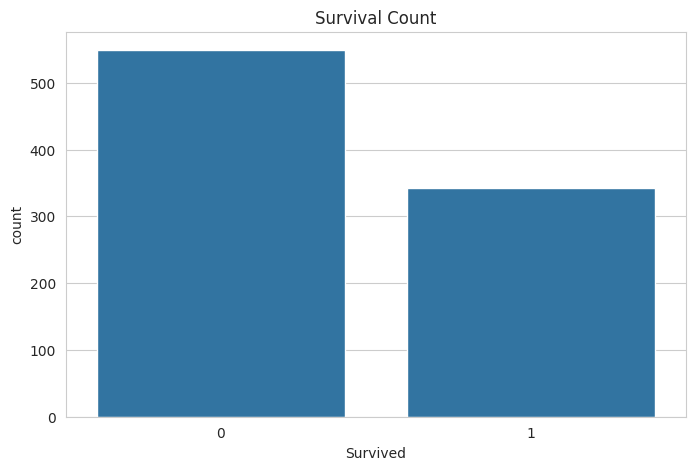

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Survived"
)

plt.title("Survival Count")

plt.savefig("plot1_survival.png")

plt.show()

Plot 2: Survival by Gender

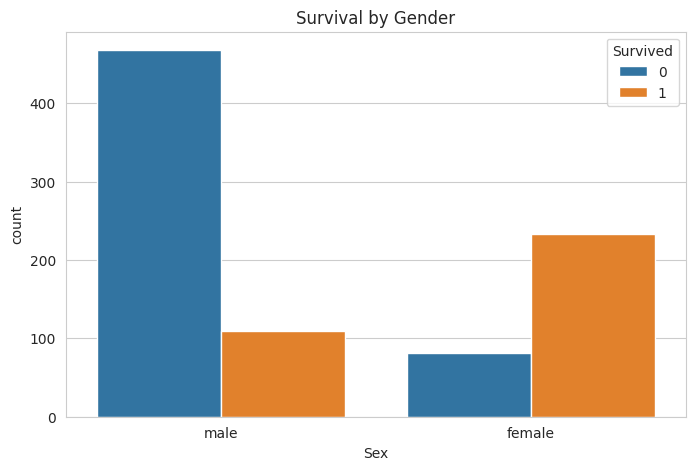

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")

plt.savefig("plot2_gender_survival.png")

plt.show()

Plot 3: Age Distribution

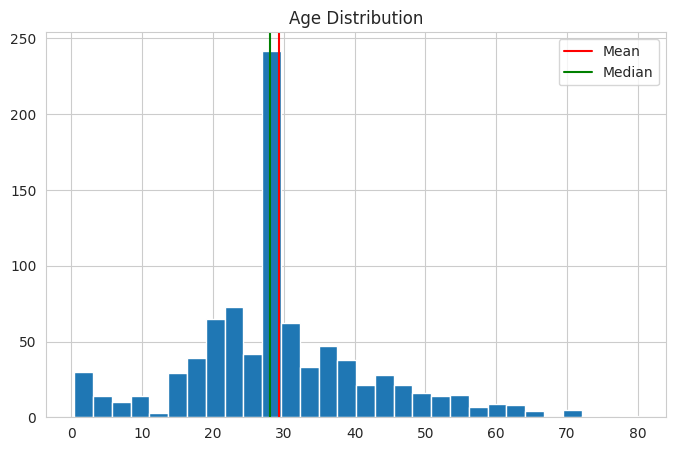

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=30
)

plt.axvline(
    df["Age"].mean(),
    color="red",
    label="Mean"
)

plt.axvline(
    df["Age"].median(),
    color="green",
    label="Median"
)

plt.legend()

plt.title("Age Distribution")

plt.savefig("plot3_age_histogram.png")

plt.show()

Plot 4: Fare Distribution

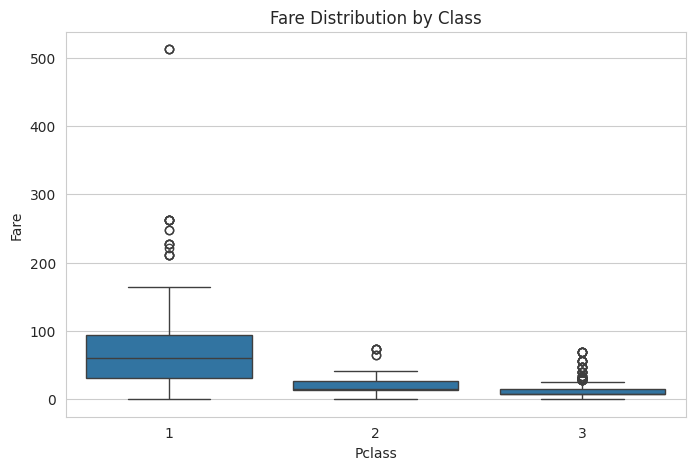

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare"
)

plt.title("Fare Distribution by Class")

plt.savefig("plot4_fare_boxplot.png")

plt.show()

Plot 5: Age vs Survival

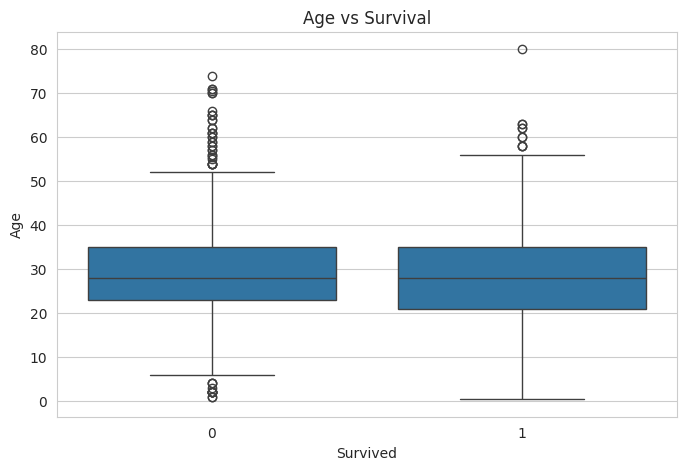

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Survived",
    y="Age"
)

plt.title("Age vs Survival")

plt.savefig("plot5_age_survival.png")

plt.show()

Plot 6: Correlation Heatmap

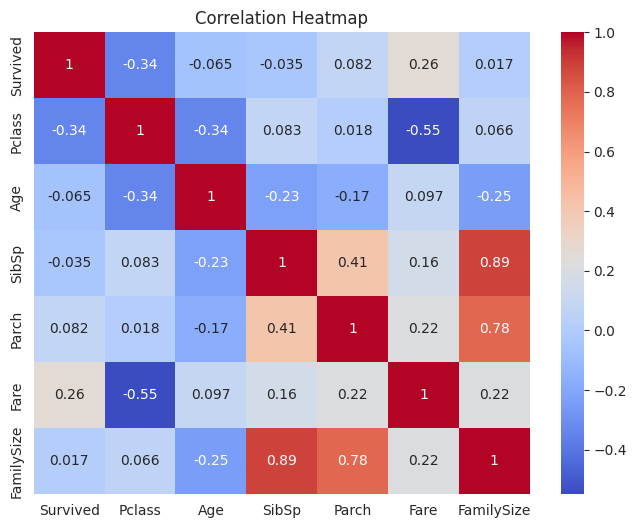

In [18]:
plt.figure(figsize=(8,6))

corr = df[
    ["Survived","Pclass","Age","SibSp",
     "Parch","Fare","FamilySize"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("plot6_heatmap.png")

plt.show()

Plot 7: Embarked Pie Chart

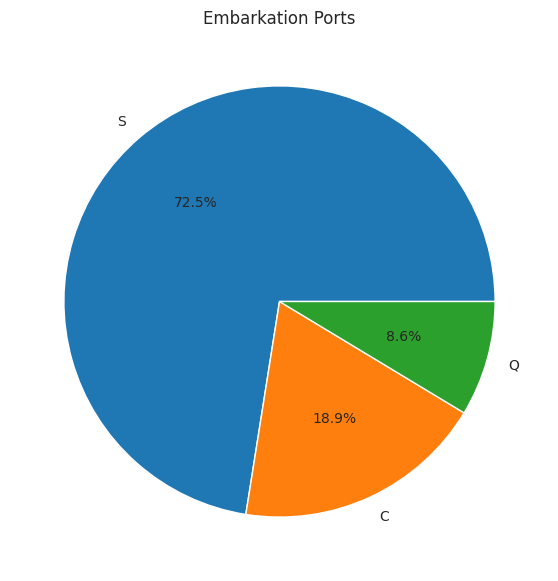

In [19]:
embarked = df["Embarked"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    embarked,
    labels=embarked.index,
    autopct="%1.1f%%"
)

plt.title("Embarkation Ports")

plt.savefig("plot7_pie_chart.png")

plt.show()

Plot 8: Survival by Passenger Class

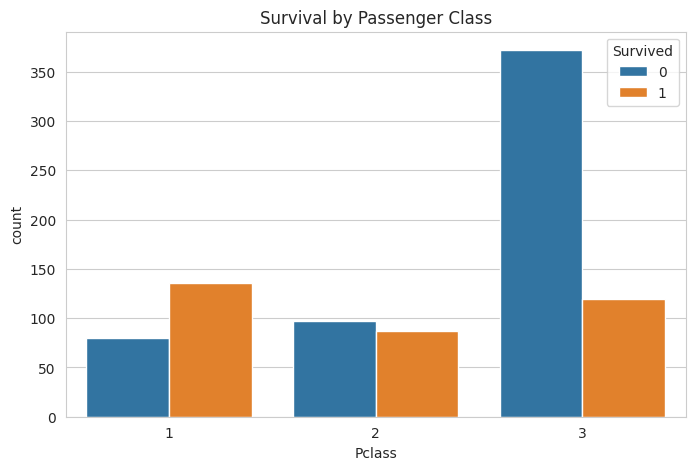

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")

plt.savefig("plot8_class_survival.png")

plt.show()

Plot 9: Violin Plot

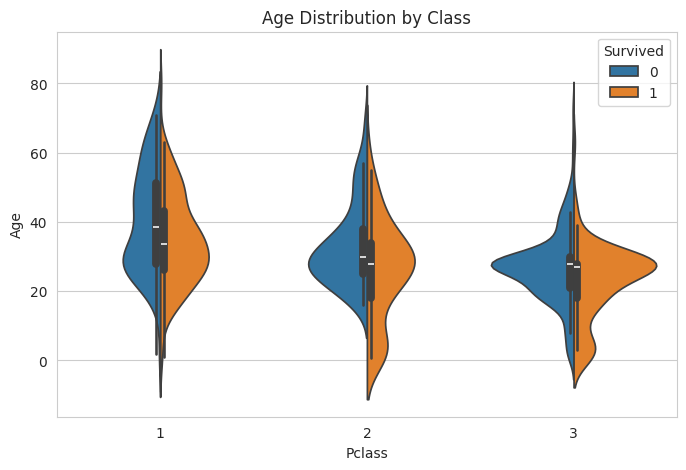

In [21]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Pclass",
    y="Age",
    hue="Survived",
    split=True
)

plt.title("Age Distribution by Class")

plt.savefig("plot9_violin.png")

plt.show()

Plot 10: Pair Plot

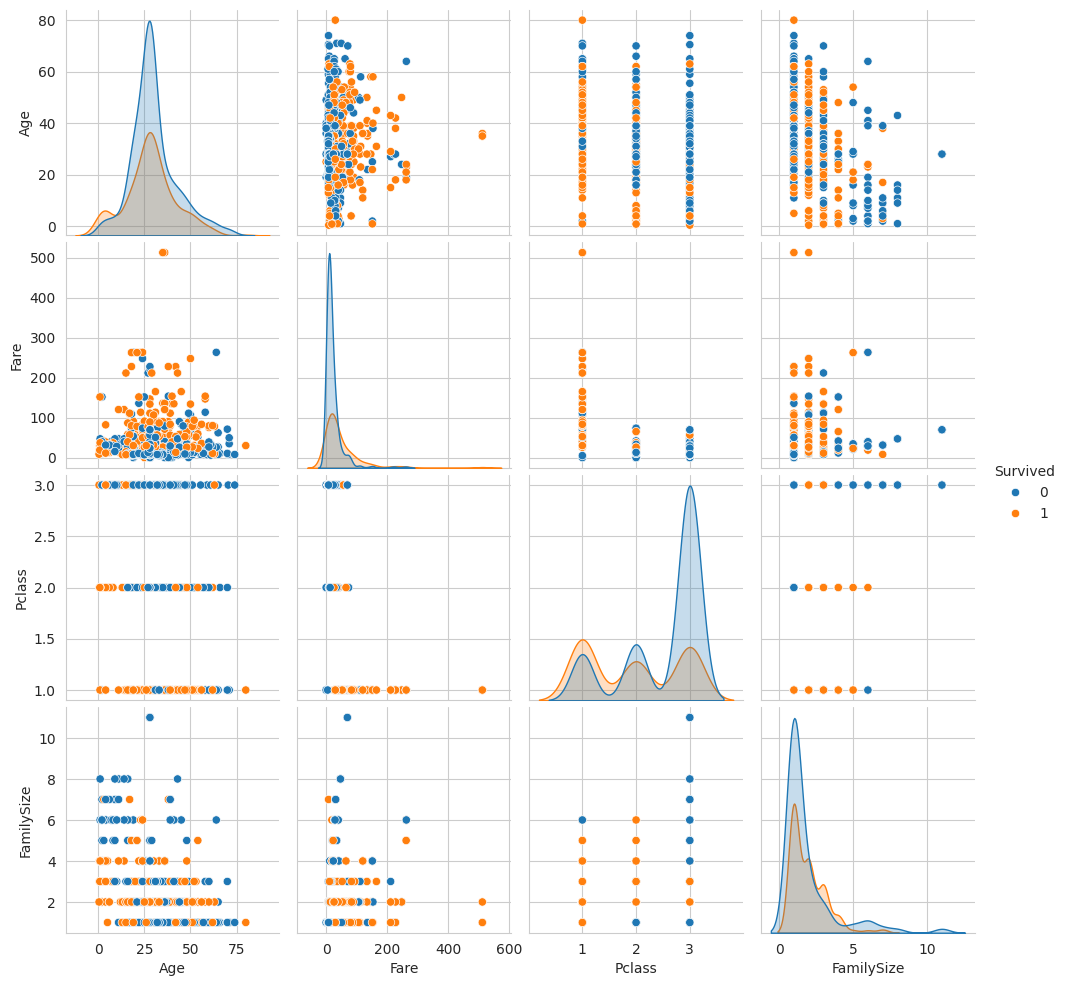

In [22]:
sns.pairplot(
    df[
        ["Survived",
         "Age",
         "Fare",
         "Pclass",
         "FamilySize"]
    ],
    hue="Survived"
)

plt.savefig("plot10_pairplot.png")

plt.show()

Final Summary Cell

In [23]:
print("="*50)

total = len(df)

survived = df["Survived"].sum()

print("Total Passengers:", total)

print(
    "Total Survivors:",
    survived,
    "(",
    round((survived/total)*100,2),
    "%)"
)

print(
    "Total Deaths:",
    total-survived
)

print("\nSurvival By Gender")

print(
    df.groupby("Sex")["Survived"].mean()*100
)

print("\nSurvival By Class")

print(
    df.groupby("Pclass")["Survived"].mean()*100
)

print("\nTop Insight:")

print(
    "Women and First-Class passengers had higher survival rates."
)

print("="*50)

Total Passengers: 891
Total Survivors: 342 ( 38.38 %)
Total Deaths: 549

Survival By Gender
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival By Class
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Top Insight:
Women and First-Class passengers had higher survival rates.


# **Report - Titanic Dataset Analysis Summary**

The Titanic dataset was analyzed using Python, Pandas, Matplotlib, and Seaborn. Data cleaning was performed by handling missing values, removing duplicates, and creating new features such as AgeGroup, FamilySize, and IsAlone. Exploratory Data Analysis revealed that only around 38% of passengers survived the disaster.

Gender played a major role in survival. Female passengers had a significantly higher survival rate compared to males. Passenger class also influenced survival, with first-class passengers showing the highest survival percentage and third-class passengers the lowest.

Age distribution analysis showed that most passengers were young adults. Correlation analysis indicated that passengers who paid higher fares generally had a better chance of survival. Visualizations such as histograms, box plots, heatmaps, pie charts, violin plots, and pair plots helped identify patterns and relationships in the data.

The analysis suggests that gender, passenger class, and fare were the most important factors affecting survival. Women, children, and first-class passengers were given priority during evacuation, leading to higher survival rates. This project provided practical experience in data cleaning, exploratory data analysis, feature engineering, and professional data visualization using Python libraries.